<a href="https://colab.research.google.com/github/sindla97/Machine-Learning/blob/main/census_bureau.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [3]:
columns=pd.read_csv('/content/census-bureau.columns',sep=',',names=['columns'])
columns['columns']=columns['columns'].str.replace(' ','_')
columns

,columns
0,age
1,class_of_worker
2,detailed_industry_recode
3,detailed_occupation_recode
4,education
5,wage_per_hour
6,enroll_in_edu_inst_last_wk
7,marital_stat
8,major_industry_code
9,major_occupation_code


In [4]:
df=pd.read_csv('/content/census-bureau.data', sep=",",names=columns['columns'].tolist())
df.head()

,age,class_of_worker,detailed_industry_recode,detailed_occupation_recode,education,wage_per_hour,enroll_in_edu_inst_last_wk,marital_stat,major_industry_code,major_occupation_code,...,country_of_birth_father,country_of_birth_mother,country_of_birth_self,citizenship,own_business_or_self_employed,fill_inc_questionnaire_for_veteran's_admin,veterans_benefits,weeks_worked_in_year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


In [5]:
#found missing values in hispanic_origin	column <1%
df.isna().sum().reset_index(name='p').sort_values(by='p',ascending=False)

,index,p
11,hispanic_origin,874
0,age,0
2,detailed_industry_recode,0
3,detailed_occupation_recode,0
4,education,0
5,wage_per_hour,0
6,enroll_in_edu_inst_last_wk,0
7,marital_stat,0
8,major_industry_code,0
1,class_of_worker,0


In [6]:
#imputing with the most popular category
df['hispanic_origin']=np.where(df['hispanic_origin'].isna(),'All other', df['hispanic_origin'])

In [7]:
df['detailed_occupation_recode']=df['detailed_occupation_recode'].astype('object')
df['detailed_industry_recode']=df['detailed_industry_recode'].astype('object')
df['veterans_benefits']=df['veterans_benefits'].astype('int').astype('object')
df['own_business_or_self_employed']=df['own_business_or_self_employed'].astype('int').astype('object')


In [8]:
df.shape

(199523, 42)

In [9]:
df['label']=df['label'].apply(lambda x: 1 if x=='50000+.' else 0)
# df['label']=df['label'].astype('category')

In [ ]:
df['label'].value_counts()

,count
label,
0,187141
1,12382


In [ ]:
df.groupby('label')['weight'].mean()

,weight
label,
0,1730.635250
1,1789.411021


In [ ]:
(df.groupby('label')['weight'].sum()/df['weight'].sum())*100

,weight
label,
0,93.594958
1,6.405042


In [10]:
unique_cnt=[]
data_type_df=df.dtypes.reset_index(name='data_type')
data_type_df

for i in data_type_df['index'].tolist():
  #print(data_type_df.loc[data_type_df['index']==i,'data_type'])
  if data_type_df.loc[data_type_df['index'] == i, 'data_type'].iloc[0] == 'object':
    unique_cnt.append(df[i].nunique())
  else: unique_cnt.append(0)
#print(unique_cnt)
data_type_df['nunique']=pd.Series(unique_cnt)
data_type_df

# df['class_of_worker'].unique().tolist()

,index,data_type,nunique
0,age,int64,0
1,class_of_worker,object,9
2,detailed_industry_recode,object,52
3,detailed_occupation_recode,object,47
4,education,object,17
5,wage_per_hour,int64,0
6,enroll_in_edu_inst_last_wk,object,3
7,marital_stat,object,7
8,major_industry_code,object,24
9,major_occupation_code,object,15


(array([13.,  8.,  1.,  1.,  1.,  0.,  1.,  0.,  3.,  3.]),
 array([ 2. ,  6.9, 11.8, 16.7, 21.6, 26.5, 31.4, 36.3, 41.2, 46.1, 51. ]),
 <BarContainer object of 10 artists>)

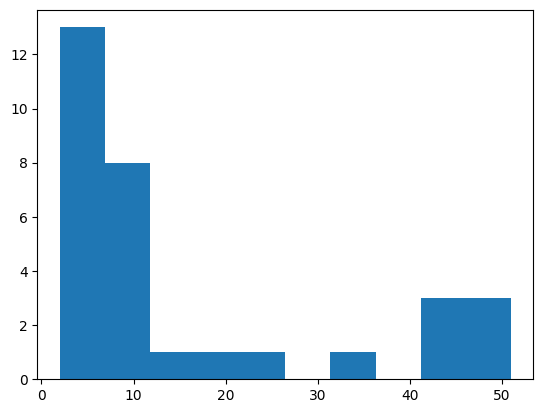

In [ ]:
import matplotlib.pyplot as plt
plt.hist(data_type_df.loc[data_type_df['data_type']=='object',['nunique']])
# data_type_df.loc[data_type_df['data_type']=='object',['nunique']].plot.density()

In [ ]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k, r) - 1)))

v_father_mother = cramers_v(df['country_of_birth_father'], df['country_of_birth_mother'])
v_father_self   = cramers_v(df['country_of_birth_father'], df['country_of_birth_self'])
v_mother_self   = cramers_v(df['country_of_birth_mother'], df['country_of_birth_self'])
print(f'v_father_mother:{v_father_mother}; v_father_self:{v_father_self}; v_mother_self:{v_mother_self}' )

v_father_mother:0.7736623864330392; v_father_self:0.6737821673082836; v_mother_self:0.6975523224864765


In [11]:
target='label'
sample_weight='weight'
cat_l_cardinal_col= [x for x in data_type_df.loc[(data_type_df['data_type']=='object') &(data_type_df['nunique']<=4),'index'].tolist() if x not in [target,sample_weight]]
cat_h_cardinal_col= [x for x in data_type_df.loc[data_type_df['data_type']=='object','index'].tolist() if x not in [target,sample_weight]+cat_l_cardinal_col]
int_columns= [x for x in data_type_df.loc[data_type_df['data_type']=='int64','index'].tolist() if x not in [target,sample_weight]]
print(len(cat_l_cardinal_col), len(cat_h_cardinal_col), len(int_columns))

8 24 8


In [ ]:
[x for x in df.columns if x not in cat_l_cardinal_col+cat_h_cardinal_col+int_columns]

['weight', 'label']

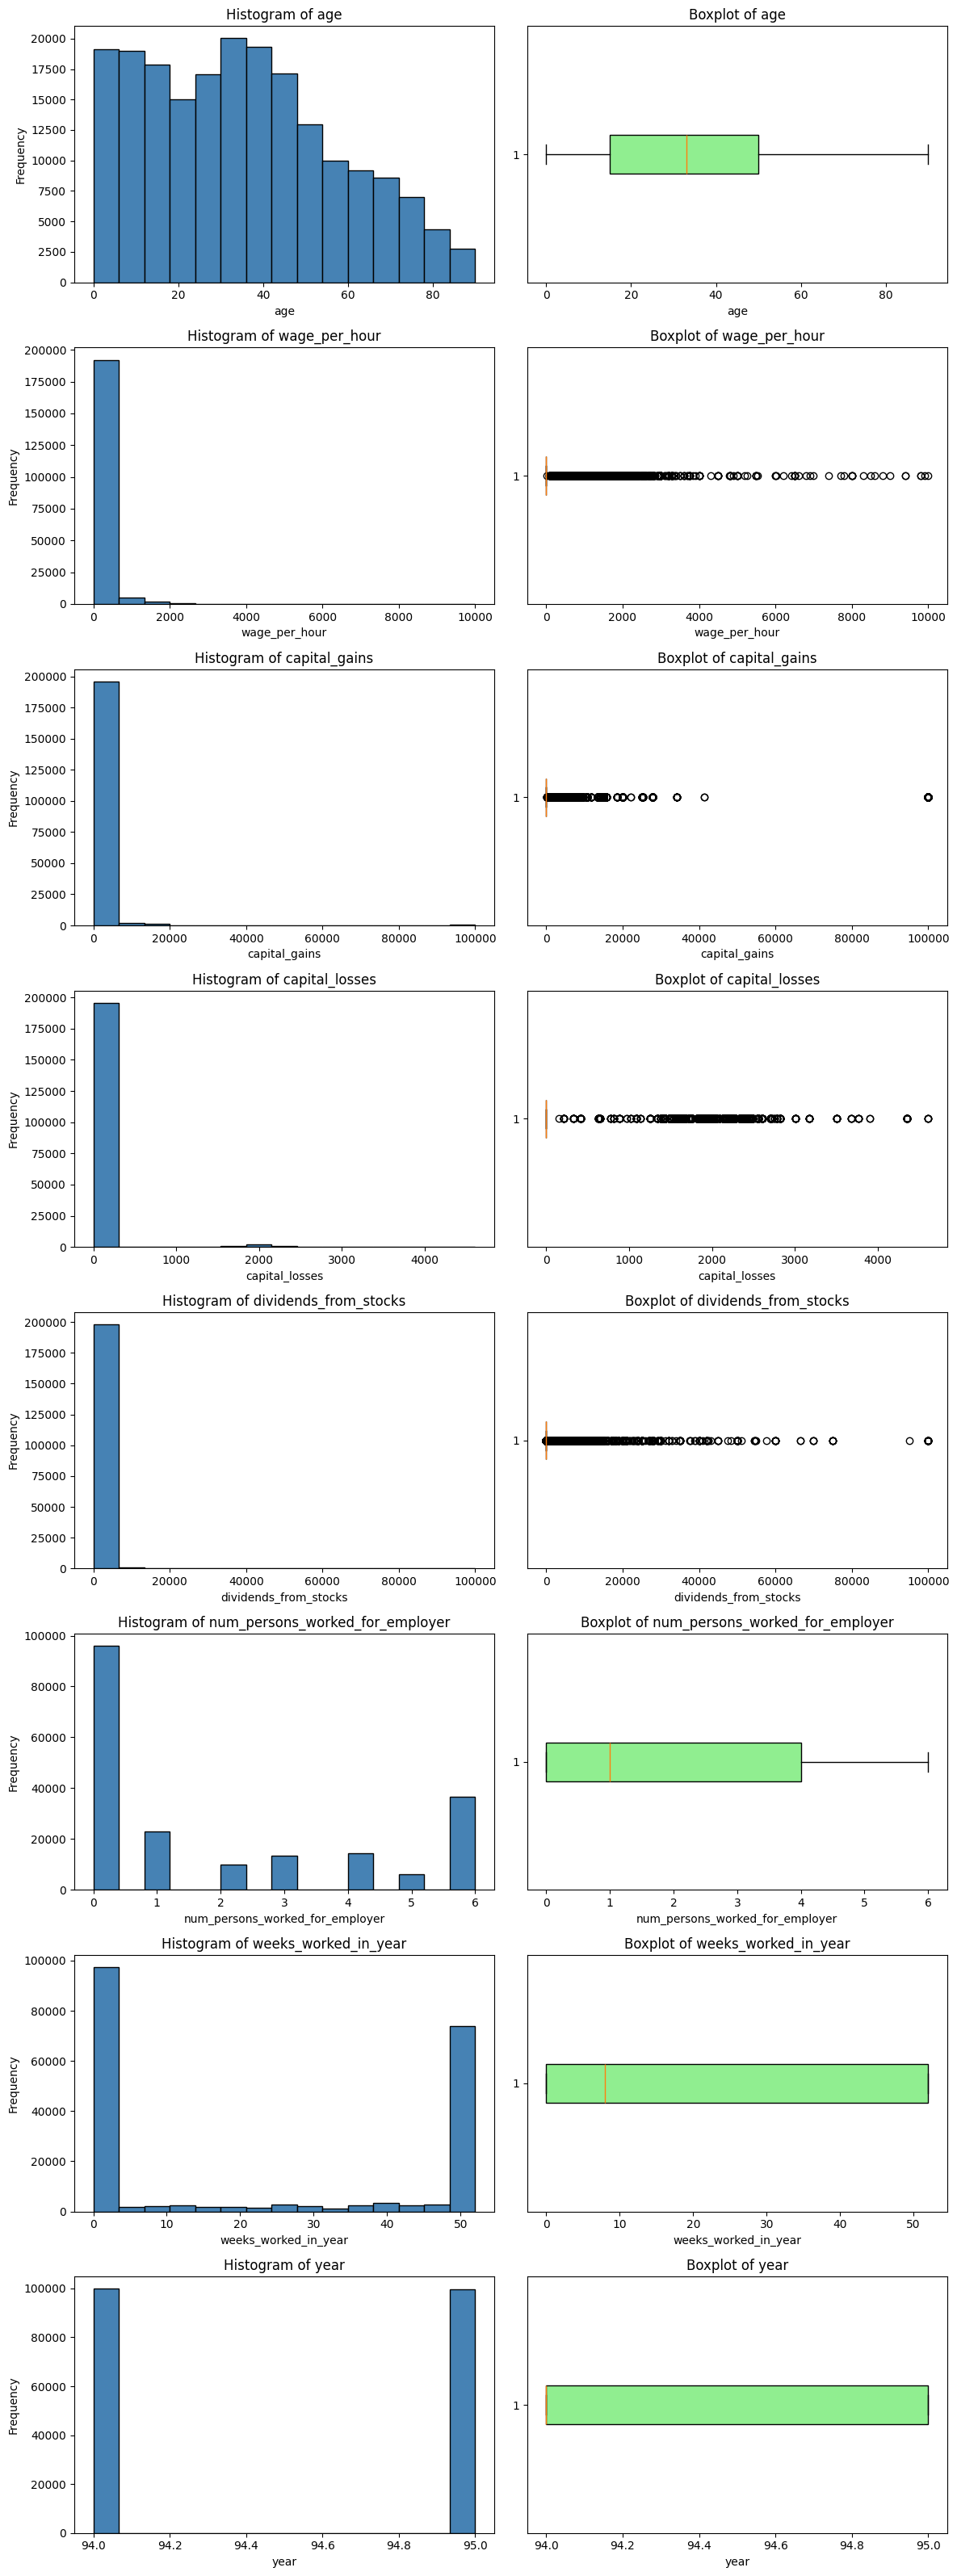

In [12]:
import matplotlib.pyplot as plt
n = len(int_columns)   # number of integer features

# Create the figure and axes
fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, 4*n))

if n == 1:
    axes = np.expand_dims(axes, axis=0)

# Loop through each integer column
for i, col in enumerate(int_columns):
    axes[i, 0].hist(df[col], bins=15, color='steelblue', edgecolor='black')
    axes[i, 0].set_title(f'Histogram of {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')

    # Boxplot
    axes[i, 1].boxplot(df[col], vert=False, patch_artist=True,
                       boxprops=dict(facecolor='lightgreen', color='black'))
    axes[i, 1].set_title(f'Boxplot of {col}')
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.show()

In [13]:
df.replace({'?': 'unknown'}, inplace=True)


/tmp/ipython-input-2489076534.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'?': 'unknown'}, inplace=True)


In [14]:
cat_feat_exp = pd.DataFrame()

for i in cat_h_cardinal_col:
  v_counts=df[i].value_counts().reset_index(name='value_counts').rename(columns={f'{i}':'values'})
  v_counts['value_counts_percent']=(v_counts['value_counts']/df.shape[0])*100
  v_meantarget=df.groupby(i)[target].mean().reset_index(name='meantarget').rename(columns={f'{i}':'values'})
  merge_df=v_counts.merge(v_meantarget, on='values', how='left')
  merge_df['feature']=i
  cat_feat_exp=pd.concat([cat_feat_exp,merge_df], axis=0,ignore_index=True)
cat_feat_exp


,values,value_counts,value_counts_percent,meantarget,feature
0,Not in universe,100245,50.242328,0.009018,class_of_worker
1,Private,72028,36.100099,0.101655,class_of_worker
2,Self-employed-not incorporated,8445,4.232595,0.129070,class_of_worker
3,Local government,7784,3.901305,0.108813,class_of_worker
4,State government,4227,2.118553,0.114739,class_of_worker
...,...,...,...,...,...
471,Native- Born in the United States,176992,88.707568,0.062992,citizenship
472,Foreign born- Not a citizen of U S,13401,6.716519,0.036714,citizenship
473,Foreign born- U S citizen by naturalization,5855,2.934499,0.099061,citizenship
474,Native- Born abroad of American Parent(s),1756,0.880099,0.072893,citizenship


In [15]:
hcard_converge=cat_feat_exp[((cat_feat_exp['value_counts_percent']<=10)&(cat_feat_exp['meantarget']<=0.07)) |((cat_feat_exp['value_counts_percent']<=0.05) &(cat_feat_exp['meantarget']<=0.5))]



In [16]:
for i in cat_h_cardinal_col:
  comp_cat = hcard_converge.loc[hcard_converge['feature'] == i, 'values'].tolist()

  df[i] = df[i].where(~df[i].isin(comp_cat), 'other')
  # print(df[i].value_counts())

In [ ]:
cat_feat_exp[cat_feat_exp['feature']=='hispanic_origin']

,values,value_counts,value_counts_percent,meantarget,feature
176,All other,172781,86.597034,0.068433,hispanic_origin
177,Mexican-American,8079,4.049157,0.021290,hispanic_origin
178,Mexican (Mexicano),7234,3.625647,0.011335,hispanic_origin
179,Central or South American,3895,1.952156,0.020539,hispanic_origin
180,Puerto Rican,3313,1.660460,0.020525,hispanic_origin
181,Other Spanish,2485,1.245470,0.032596,hispanic_origin
182,Cuban,1126,0.564346,0.054174,hispanic_origin
183,Do not know,306,0.153366,0.026144,hispanic_origin
184,Chicano,304,0.152363,0.019737,hispanic_origin


In [ ]:
cat_feat_exp[(cat_feat_exp['feature']=='country_of_birth_self') &(cat_feat_exp['values']=='Hong Kong')]

,values,value_counts,value_counts_percent,meantarget,feature
463,Hong Kong,100,0.05012,0.1,country_of_birth_self


In [ ]:
df[int_columns].describe()

,age,wage_per_hour,capital_gains,capital_losses,dividends_from_stocks,num_persons_worked_for_employer,weeks_worked_in_year,year
count,199523.000000,199523.000000,199523.00000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000
mean,34.494199,55.426908,434.71899,37.313788,197.529533,1.956180,23.174897,94.499672
std,22.310895,274.896454,4697.53128,271.896428,1984.163658,2.365126,24.411488,0.500001
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,94.000000
25%,15.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,94.000000
50%,33.000000,0.000000,0.00000,0.000000,0.000000,1.000000,8.000000,94.000000
75%,50.000000,0.000000,0.00000,0.000000,0.000000,4.000000,52.000000,95.000000
max,90.000000,9999.000000,99999.00000,4608.000000,99999.000000,6.000000,52.000000,95.000000


In [17]:
for i in int_columns:
  if i in ['wage_per_hour','capital_gains','capital_losses','dividends_from_stocks']:
    df[i]=np.where(df[i]==0,0, np.log1p(df[i]))


In [ ]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(df[['age']], df['label'])
print(mi)

[0.03795227]


In [31]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(
    df,
    random_state=42,
test_size=0.3,stratify=df[target])

In [19]:
print(train_df[target].value_counts(), test_df[target].value_counts())

label
0    130999
1      8667
Name: count, dtype: int64 label
0    56142
1     3715
Name: count, dtype: int64


In [20]:
import warnings
warnings.filterwarnings('ignore')

In [32]:
global_mean = train_df[target].mean()

for feature in cat_h_cardinal_col:

  mean_map = train_df.groupby(feature)[target].mean()


  train_df[f'{feature}_enc_mt'] = train_df[feature].map(mean_map)
  test_df[f'{feature}_enc_mt']  = test_df[feature].map(mean_map)

  pop_map = train_df[feature].value_counts()/train_df.shape[0]
  train_df[f'{feature}_enc_pop'] = train_df[feature].map(pop_map)
  test_df[f'{feature}_enc_pop']  = test_df[feature].map(pop_map)

# Handle unknown categories in test
  test_df[f'{feature}_enc_mt'].fillna(global_mean, inplace=True)
  test_df[f'{feature}_enc_pop'].fillna(global_mean, inplace=True)

In [ ]:
train_df.describe()

,age,wage_per_hour,capital_gains,capital_losses,dividends_from_stocks,weight,num_persons_worked_for_employer,own_business_or_self_employed,veterans_benefits,weeks_worked_in_year,...,family_members_under_18_enc_mt,family_members_under_18_enc_pop,country_of_birth_father_enc_mt,country_of_birth_father_enc_pop,country_of_birth_mother_enc_mt,country_of_birth_mother_enc_pop,country_of_birth_self_enc_mt,country_of_birth_self_enc_pop,citizenship_enc_mt,citizenship_enc_pop
count,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,...,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000,139666.000000
mean,34.468983,0.383485,0.321683,0.148939,0.605584,1740.683954,1.955050,0.176063,1.513640,23.152614,...,0.062055,0.566402,0.062055,0.650789,0.062055,0.661364,0.062055,0.790629,0.062055,0.792639
std,22.315965,1.566097,1.652333,1.048657,1.887546,994.066463,2.365581,0.554511,0.852232,24.405993,...,0.038487,0.252320,0.016423,0.290001,0.016325,0.287776,0.014415,0.268435,0.009840,0.262831
min,0.000000,0.000000,0.000000,0.000000,0.000000,37.870000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.082268,0.024439,0.000580,0.025158,0.000945,0.021926,0.000444,0.035190,0.008706
25%,15.000000,0.000000,0.000000,0.000000,0.000000,1061.570000,0.000000,0.000000,2.000000,0.000000,...,0.000037,0.195695,0.064790,0.796772,0.064816,0.803302,0.063000,0.886579,0.062999,0.886594
50%,33.000000,0.000000,0.000000,0.000000,0.000000,1617.895000,1.000000,0.000000,2.000000,8.000000,...,0.085935,0.722037,0.064790,0.796772,0.064816,0.803302,0.063000,0.886579,0.062999,0.886594
75%,50.000000,0.000000,0.000000,0.000000,0.000000,2189.980000,4.000000,0.000000,2.000000,52.000000,...,0.085935,0.722037,0.064790,0.796772,0.064816,0.803302,0.063000,0.886579,0.062999,0.886594
max,90.000000,9.210340,11.512925,8.435766,11.512925,18656.300000,6.000000,2.000000,2.000000,52.000000,...,0.085935,0.722037,0.140436,0.796772,0.151515,0.803302,0.186916,0.886579,0.099347,0.886594


##Linear Model (base Line comparison)


In [ ]:
#Linear model
#1. combine all features remove the original high cardinal categorical features and repalce with encoded features
#2. perfrom standard scalar
#3. one hot encode and retain the low cardinal (<=4 categories) fetaures.
#calcualte the class weights
# use sample_weights
# train model

In [22]:
cat_l_cardinal_col_encoded=[]
from sklearn.preprocessing import OneHotEncoder
for i in cat_l_cardinal_col:
# i='enroll_in_edu_inst_last_wk'
  oe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')


  train_encoded = oe.fit_transform(train_df[[i]])

  test_encoded = oe.transform(test_df[[i]])

  encoded_cols = oe.get_feature_names_out([i])

  train_encoded_df = pd.DataFrame(train_encoded, columns=encoded_cols, index=train_df.index)
  test_encoded_df = pd.DataFrame(test_encoded, columns=encoded_cols, index=test_df.index)

  train_df = pd.concat([train_df, train_encoded_df], axis=1)
  test_df = pd.concat([test_df, test_encoded_df], axis=1)
  cat_l_cardinal_col_encoded.extend(encoded_cols)


In [23]:
final_features_lr=[x for x in int_columns if x not in ['year']]+cat_l_cardinal_col_encoded+[ f'{x}_enc_mt' for x in cat_h_cardinal_col]+[f'{x}_enc_pop' for x in cat_h_cardinal_col]
final_features_lr

['age',
 'wage_per_hour',
 'capital_gains',
 'capital_losses',
 'dividends_from_stocks',
 'num_persons_worked_for_employer',
 'weeks_worked_in_year',
 'enroll_in_edu_inst_last_wk_College or university',
 'enroll_in_edu_inst_last_wk_High school',
 'enroll_in_edu_inst_last_wk_Not in universe',
 'sex_Female',
 'sex_Male',
 'member_of_a_labor_union_No',
 'member_of_a_labor_union_Not in universe',
 'member_of_a_labor_union_Yes',
 'live_in_this_house_1_year_ago_No',
 'live_in_this_house_1_year_ago_Not in universe under 1 year old',
 'live_in_this_house_1_year_ago_Yes',
 'migration_prev_res_in_sunbelt_No',
 'migration_prev_res_in_sunbelt_Not in universe',
 'migration_prev_res_in_sunbelt_Yes',
 'migration_prev_res_in_sunbelt_unknown',
 'own_business_or_self_employed_0',
 'own_business_or_self_employed_1',
 'own_business_or_self_employed_2',
 "fill_inc_questionnaire_for_veteran's_admin_No",
 "fill_inc_questionnaire_for_veteran's_admin_Not in universe",
 "fill_inc_questionnaire_for_veteran's_adm

In [24]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
train_df_final=ss.fit_transform(train_df[final_features_lr])
test_df_final=ss.transform(test_df[final_features_lr])

In [ ]:
train_df.isna().sum().reset_index(name='p').sort_values(by='p',ascending=False)

,index,p
0,age,0
1,class_of_worker,0
2,detailed_industry_recode,0
3,detailed_occupation_recode,0
4,education,0
...,...,...
109,fill_inc_questionnaire_for_veteran's_admin_Not...,0
110,fill_inc_questionnaire_for_veteran's_admin_Yes,0
111,veterans_benefits_0,0
112,veterans_benefits_1,0


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import RandomizedSearchCV

In [44]:

lr=LogisticRegression(class_weight='balanced' )
lr.fit(train_df_final, train_df[target],sample_weight=train_df[sample_weight])
y_predict=lr.predict(test_df_final)


In [ ]:
print(classification_report(test_df[target],y_predict,sample_weight=test_df[sample_weight]))

              precision    recall  f1-score   support

           0       0.99      0.85      0.91 97425847.33000034
           1       0.29      0.89      0.44 6705680.059999989

    accuracy                           0.85 104131527.39000033
   macro avg       0.64      0.87      0.68 104131527.39000033
weighted avg       0.95      0.85      0.88 104131527.39000033



In [ ]:
coef = pd.DataFrame(data={'features':final_features_lr,'coefficient':lr.coef_[0], 'abs_coefficient':abs(lr.coef_[0]) })
coef.sort_values(by='abs_coefficient',ascending=False).head(10)

,features,coefficient,abs_coefficient
60,major_industry_code_enc_pop,1.092214,1.092214
46,detailed_household_summary_in_household_enc_mt,0.997959,0.997959
42,tax_filer_stat_enc_mt,0.743875,0.743875
6,weeks_worked_in_year,0.713493,0.713493
0,age,0.619119,0.619119
28,veterans_benefits_0,-0.545780,0.545780
30,veterans_benefits_2,0.525746,0.525746
70,detailed_household_summary_in_household_enc_pop,-0.501599,0.501599
56,detailed_industry_recode_enc_pop,-0.411823,0.411823
34,education_enc_mt,0.392456,0.392456


In [ ]:

param_grid = {
    # Regularization strength
    "C": [ 0.01, 0.1, 1, 10],
    "solver": ["saga", "lbfgs"],
    "l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0],
    "max_iter": [ 500, 1000],
    "fit_intercept": [True, False],

}


lr_cv=LogisticRegression(class_weight='balanced',random_state=42,penalty='elasticnet', tol= 1e-4)
random_search = RandomizedSearchCV(
    estimator=lr_cv,
    param_distributions=param_grid,
    cv=2,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=5, n_iter=5
)
random_search.fit(train_df_final, train_df[target],sample_weight=train_df[sample_weight])


Fitting 2 folds for each of 5 candidates, totalling 10 fits


RandomizedSearchCV(cv=2,
                   estimator=LogisticRegression(class_weight='balanced',
                                                penalty='elasticnet',
                                                random_state=42),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'C': [0.01, 0.1, 1, 10],
                                        'fit_intercept': [True, False],
                                        'l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0],
                                        'max_iter': [500, 1000],
                                        'solver': ['saga', 'lbfgs']},
                   scoring='roc_auc', verbose=5)

In [ ]:
y_test_predict_lr_cv=random_search.predict(test_df_final)
print(classification_report(test_df[target],y_test_predict_lr_cv, sample_weight=test_df[sample_weight]))

              precision    recall  f1-score   support

           0       0.99      0.81      0.89 97425847.33000034
           1       0.23      0.85      0.37 6705680.059999989

    accuracy                           0.81 104131527.39000033
   macro avg       0.61      0.83      0.63 104131527.39000033
weighted avg       0.94      0.81      0.86 104131527.39000033



In [ ]:
coef = pd.DataFrame(data={'features':final_features_lr,'coefficient':random_search.best_estimator_.coef_[0], 'abs_coefficient':abs(random_search.best_estimator_.coef_[0]) })
coef.sort_values(by='abs_coefficient',ascending=False).head(10)

,features,coefficient,abs_coefficient
74,family_members_under_18_enc_pop,2217.815727,2217.815727
50,family_members_under_18_enc_mt,-2121.583741,2121.583741
28,veterans_benefits_0,-1719.274170,1719.274170
30,veterans_benefits_2,1659.766983,1659.766983
60,major_industry_code_enc_pop,756.032456,756.032456
42,tax_filer_stat_enc_mt,594.734716,594.734716
6,weeks_worked_in_year,546.686986,546.686986
0,age,543.291233,543.291233
46,detailed_household_summary_in_household_enc_mt,510.847732,510.847732
32,detailed_industry_recode_enc_mt,438.434672,438.434672


#Boosting model

In [33]:
final_features_boost=[x for x in int_columns if x not in ['year']]+cat_l_cardinal_col+[ f'{x}_enc_mt' for x in cat_h_cardinal_col]+[f'{x}_enc_pop' for x in cat_h_cardinal_col]
final_features_boost

['age',
 'wage_per_hour',
 'capital_gains',
 'capital_losses',
 'dividends_from_stocks',
 'num_persons_worked_for_employer',
 'weeks_worked_in_year',
 'enroll_in_edu_inst_last_wk',
 'sex',
 'member_of_a_labor_union',
 'live_in_this_house_1_year_ago',
 'migration_prev_res_in_sunbelt',
 'own_business_or_self_employed',
 "fill_inc_questionnaire_for_veteran's_admin",
 'veterans_benefits',
 'class_of_worker_enc_mt',
 'detailed_industry_recode_enc_mt',
 'detailed_occupation_recode_enc_mt',
 'education_enc_mt',
 'marital_stat_enc_mt',
 'major_industry_code_enc_mt',
 'major_occupation_code_enc_mt',
 'race_enc_mt',
 'hispanic_origin_enc_mt',
 'reason_for_unemployment_enc_mt',
 'full_or_part_time_employment_stat_enc_mt',
 'tax_filer_stat_enc_mt',
 'region_of_previous_residence_enc_mt',
 'state_of_previous_residence_enc_mt',
 'detailed_household_and_family_stat_enc_mt',
 'detailed_household_summary_in_household_enc_mt',
 'migration_code-change_in_msa_enc_mt',
 'migration_code-change_in_reg_enc_mt

In [45]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.4 MB/s eta 0:00:00


In [50]:
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(train_df[target])

weights = compute_class_weight(class_weight='balanced',
                               classes=classes,
                               y=train_df[target])
weights

array([0.53308041, 8.05734395])

In [54]:
from catboost import CatBoostClassifier,Pool


# Initialize model
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=10,
    loss_function='Logloss',
    eval_metric='AUC',
    class_weights=[weights[0], weights[1]],
    random_seed=42,
    verbose=100,early_stopping_rounds=50
)

train_pool = Pool(
    data=train_df[final_features_boost],
    label=train_df[target],
    weight=train_df[sample_weight],
    cat_features=cat_l_cardinal_col
)

eval_pool = Pool(
    data=test_df[final_features_boost],
    label=test_df[target],
    weight=test_df[sample_weight],
    cat_features=cat_l_cardinal_col
)

model.fit(train_pool, eval_set=eval_pool,use_best_model=True)




0:	test: 0.8636743	best: 0.8636743 (0)	total: 1.53s	remaining: 25m 24s
100:	test: 0.9350103	best: 0.9350455 (95)	total: 44.5s	remaining: 6m 36s
200:	test: 0.9388814	best: 0.9388814 (200)	total: 1m 39s	remaining: 6m 34s
300:	test: 0.9451697	best: 0.9451697 (300)	total: 2m 31s	remaining: 5m 51s
400:	test: 0.9518859	best: 0.9518859 (400)	total: 3m 50s	remaining: 5m 43s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9520639191
bestIteration = 420

Shrink model to first 421 iterations.


In [ ]:
y_test_predict_cat=model.predict(test_df[final_features_boost])
print(classification_report(test_df[target],y_test_predict_cat, sample_weight=test_df[sample_weight]))

              precision    recall  f1-score   support

           0       0.99      0.90      0.94 97425847.33000034
           1       0.36      0.86      0.51 6705680.059999989

    accuracy                           0.89 104131527.39000033
   macro avg       0.68      0.88      0.73 104131527.39000033
weighted avg       0.95      0.89      0.91 104131527.39000033



In [ ]:

coef = pd.DataFrame(data={'features':final_features_boost,'importance':model.feature_importances_})
coef.sort_values(by='importance',ascending=False).head(10)

,features,importance
0,age,11.131446
18,education_enc_mt,6.688624
8,sex,6.421863
30,detailed_household_summary_in_household_enc_mt,4.910060
34,family_members_under_18_enc_mt,4.805231
6,weeks_worked_in_year,4.366561
58,family_members_under_18_enc_pop,3.497859
5,num_persons_worked_for_employer,3.457086
26,tax_filer_stat_enc_mt,2.765100
42,education_enc_pop,2.670143


In [ ]:
from sklearn.metrics import roc_curve,auc
roc_curve(test_df[target],y_test_predict_cat, sample_weight=test_df[sample_weight])

(array([0.        , 0.10324389, 1.        ]),
 array([0.        , 0.86046657, 1.        ]),
 array([inf,  1.,  0.]))

In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score

precision, recall, thresholds = precision_recall_curve(test_df[target], y_pred_cat)

f1_scores = 2 * (precision * recall) / (precision + recall)


optimal_idx = np.argmax(f1_scores)

optimal_threshold = thresholds[optimal_idx]
print(optimal_threshold, precision[optimal_idx], recall[optimal_idx],f1_scores[optimal_idx])

0.8470141193779126 0.6354166666666666 0.6075370121130552 0.6211641667813403


## XGBoost with label encoding on "cat_l_cardinal_col"


In [34]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in cat_l_cardinal_col:
  train_df[i]=le.fit_transform(train_df[i])
  train_df[i]=train_df[i].astype('category')
  test_df[i]=le.transform(test_df[i])
  test_df[i]=test_df[i].astype('category')


In [48]:
import xgboost
from xgboost import XGBClassifier
scale_pos_weight=(train_df[target]==0).sum()/(train_df[target]==1).sum()
print(scale_pos_weight)

xgb=XGBClassifier(    objective='binary:logistic',
    enable_categorical=True,
    eval_metric='auc',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=12,
    reg_lambda=0.3,
    reg_alpha=0.6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    early_stopping_rounds=50, verbose=1 ,scale_pos_weight=scale_pos_weight,
    n_jobs=-1)

xgb.fit(
    train_df[final_features_boost], train_df[target],
    sample_weight=train_df[sample_weight],
    eval_set=[(test_df[final_features_boost], test_df[target])],
    sample_weight_eval_set=[test_df[sample_weight]],
    verbose=True
)



15.11468789661936
[0]	validation_0-auc:0.89633
[1]	validation_0-auc:0.91291
[2]	validation_0-auc:0.92215
[3]	validation_0-auc:0.92810
[4]	validation_0-auc:0.93241
[5]	validation_0-auc:0.93676
[6]	validation_0-auc:0.93747
[7]	validation_0-auc:0.93803
[8]	validation_0-auc:0.93850
[9]	validation_0-auc:0.93888
[10]	validation_0-auc:0.93936
[11]	validation_0-auc:0.93999
[12]	validation_0-auc:0.94026
[13]	validation_0-auc:0.94037
[14]	validation_0-auc:0.94041
[15]	validation_0-auc:0.94046
[16]	validation_0-auc:0.94076
[17]	validation_0-auc:0.94047
[18]	validation_0-auc:0.94089
[19]	validation_0-auc:0.94148
[20]	validation_0-auc:0.94167
[21]	validation_0-auc:0.94207
[22]	validation_0-auc:0.94226
[23]	validation_0-auc:0.94224
[24]	validation_0-auc:0.94242
[25]	validation_0-auc:0.94253
[26]	validation_0-auc:0.94281
[27]	validation_0-auc:0.94289
[28]	validation_0-auc:0.94300
[29]	validation_0-auc:0.94295
[30]	validation_0-auc:0.94282
[31]	validation_0-auc:0.94298
[32]	validation_0-auc:0.94310
[3

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=50,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=12,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=-1, num_parallel_tree=None, ...)

In [49]:
y_test_predict_cat=xgb.predict(test_df[final_features_boost])
print(classification_report(test_df[target],y_test_predict_cat, sample_weight=test_df[sample_weight]))

              precision    recall  f1-score   support

           0       0.98      0.92      0.95 97425847.33000034
           1       0.40      0.80      0.53 6705680.059999989

    accuracy                           0.91 104131527.39000033
   macro avg       0.69      0.86      0.74 104131527.39000033
weighted avg       0.95      0.91      0.92 104131527.39000033



In [41]:
y_test_predict_cat=xgb.predict(test_df[final_features_boost])
print(classification_report(test_df[target],y_test_predict_cat, sample_weight=test_df[sample_weight]))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98 97425847.33000034
           1       0.75      0.48      0.58 6705680.059999989

    accuracy                           0.96 104131527.39000033
   macro avg       0.86      0.73      0.78 104131527.39000033
weighted avg       0.95      0.96      0.95 104131527.39000033



In [42]:
coef = pd.DataFrame(data={'features':final_features_boost,'importance':xgb.feature_importances_})
coef.sort_values(by='importance',ascending=False).head(10)

,features,importance
17,detailed_occupation_recode_enc_mt,0.128834
26,tax_filer_stat_enc_mt,0.049774
2,capital_gains,0.037950
8,sex,0.035765
21,major_occupation_code_enc_mt,0.032709
18,education_enc_mt,0.027245
41,detailed_occupation_recode_enc_pop,0.026956
29,detailed_household_and_family_stat_enc_mt,0.025904
30,detailed_household_summary_in_household_enc_mt,0.025608
50,tax_filer_stat_enc_pop,0.023518


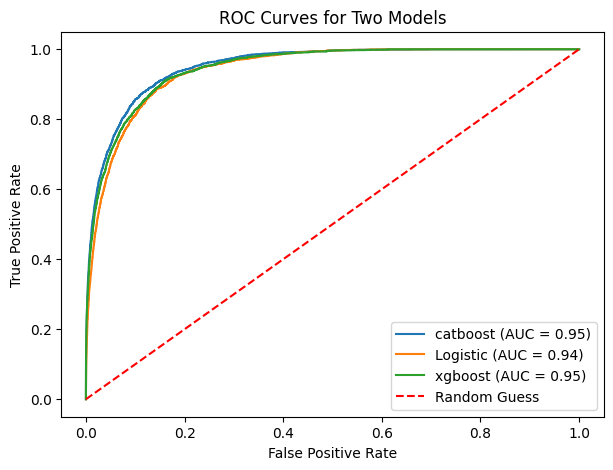

In [55]:
from sklearn.metrics import roc_curve,auc
y_pred_logistic = lr.predict_proba(test_df_final)[:, 1]
y_pred_cat = model.predict_proba(test_df[final_features_boost])[:, 1]
y_pred_xgb = xgb.predict_proba(test_df[final_features_boost])[:, 1]

tmp_df = pd.DataFrame(
    {'True': test_df[target], 'Logistic': y_pred_logistic, 'catboost': y_pred_cat, 'xgboost':y_pred_xgb})

plt.figure(figsize=(7, 5))

for i in ['catboost','Logistic', 'xgboost']:
    fpr, tpr, _ = roc_curve(tmp_df['True'], tmp_df[i],sample_weight=test_df[sample_weight])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Two Models')
plt.legend()
plt.show()

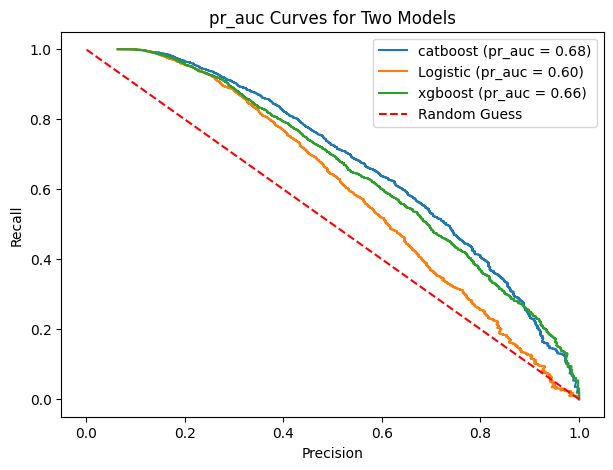

In [57]:
from sklearn.metrics import roc_curve,auc,average_precision_score,precision_recall_curve

plt.figure(figsize=(7, 5))

for i in ['catboost','Logistic','xgboost']:
    precision, recall, thresholds = precision_recall_curve(tmp_df['True'], tmp_df[i],sample_weight=test_df[sample_weight])
    pr_auc = average_precision_score(
        tmp_df['True'], tmp_df[i], sample_weight=test_df[sample_weight]
    )
    plt.plot(precision, recall, label=f'{i} (pr_auc = {pr_auc:.2f})')

plt.plot([1, 0], [0,1], 'r--', label='Random Guess')

plt.xlabel('Precision')
plt.ylabel('Recall')
plt.title('pr_auc Curves for Two Models')
plt.legend()
plt.show()